In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from scipy import stats
from scipy.stats import skew,kurtosis

## **1. Data Loading and Exploration:**

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

Le jeu de donnée présente 2000 échantillons et 21 variables :
* id (int64) - Identifiant
* battery_power (int64) - Capacité totale de la batterie (mAh)
* blue (float64) - Présence de Bluetooth
* clock_speed (inte64)- Fréquence du microprocesseur
* dual_sim (inte64)- Compatible double SIM
* fc (inte64)- Résolution de la caméra frontale (mégapixels)
* four_g (inte64)- Présence de la 4G
* int_memory (inte64)- Mémoire interne (Go)
* m_dep (float64)- Profondeur du mobile (cm)
* mobile_wt (inte64)- Poids du téléphone
* n_cores (inte64)- Nombre de cœurs du processeur
* pc (inte64)- Résolution de la caméra principale (mégapixels)
* px_height (inte64)- Hauteur de l'écran (pixels)
* px_width - Largeur de l'écran (pixels)
* ram (inte64)- Mémoire vive (Mo)
* sc_h (inte64)- Hauteur de l'écran (cm)
* sc_w (inte64)- Largeur de l'écran (cm)
* talk_time (inte64)- Autonomie maximale en conversation
* three_g (inte64)- Présence de la 3G
* touch_screen (inte64)- Présence d'un écran tactile
* wifi (inte64)- Présence du Wi-Fi
* price_range (inte64)- Variable cible (valeur : 0) (Faible coût) 
1 (medium cost)
2 (high cost)
3 (very high cost)  

Avec price_range qui est la variable cible

In [8]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


Ici on constate que les batterie on une capacité moyenne de 1238.51 mpah, une mémoire interne de 32go, une mémoire ram de 2GB, une fréquence moyenne de 1,52

## **2. Data Cleaning and Preprocessing:**

In [5]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

On remarque qu'il n'y a pas de valeur manquante

In [7]:
df.duplicated().sum()

np.int64(0)

Il n'y a pas de valeur dupliquer

De plus toute les données catégoriel sont déjà au format numérique

In [9]:
df['price_range'].unique()

array([1, 2, 3, 0])

## **3. Statistical Analysis with NumPy and SciPy:**

### **Central tendency**

Les mesures de tendance centrale permettent d'identifier la valeur représentative de chaque variable.

In [13]:
#Moyenne
mean = df.mean(numeric_only=True)
mean

battery_power    1238.51850
blue                0.49500
clock_speed         1.52225
dual_sim            0.50950
fc                  4.30950
four_g              0.52150
int_memory         32.04650
m_dep               0.50175
mobile_wt         140.24900
n_cores             4.52050
pc                  9.91650
px_height         645.10800
px_width         1251.51550
ram              2124.21300
sc_h               12.30650
sc_w                5.76700
talk_time          11.01100
three_g             0.76150
touch_screen        0.50300
wifi                0.50700
price_range         1.50000
dtype: float64

In [15]:
#Median
median = df.median()
median

battery_power    1226.0
blue                0.0
clock_speed         1.5
dual_sim            1.0
fc                  3.0
four_g              1.0
int_memory         32.0
m_dep               0.5
mobile_wt         141.0
n_cores             4.0
pc                 10.0
px_height         564.0
px_width         1247.0
ram              2146.5
sc_h               12.0
sc_w                5.0
talk_time          11.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         1.5
dtype: float64

In [18]:
#Mode
mode = df.mode().iloc[0]
mode

battery_power     618.0
blue                0.0
clock_speed         0.5
dual_sim            1.0
fc                  0.0
four_g              1.0
int_memory         27.0
m_dep               0.1
mobile_wt         182.0
n_cores             4.0
pc                 10.0
px_height         347.0
px_width          874.0
ram              1229.0
sc_h               17.0
sc_w                1.0
talk_time           7.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         0.0
Name: 0, dtype: float64

### **Analysis of variability**

Vérification de la répartition des points par rapport à la moyenne

In [20]:
#Étendue (Range)
df.max() - df.min()

battery_power    1497.0
blue                1.0
clock_speed         2.5
dual_sim            1.0
fc                 19.0
four_g              1.0
int_memory         62.0
m_dep               0.9
mobile_wt         120.0
n_cores             7.0
pc                 20.0
px_height        1960.0
px_width         1498.0
ram              3742.0
sc_h               14.0
sc_w               18.0
talk_time          18.0
three_g             1.0
touch_screen        1.0
wifi                1.0
price_range         3.0
dtype: float64

In [21]:
#Variance
df.var()

battery_power    1.930884e+05
blue             2.501001e-01
clock_speed      6.658629e-01
dual_sim         2.500348e-01
fc               1.884813e+01
four_g           2.496626e-01
int_memory       3.292670e+02
m_dep            8.318353e-02
mobile_wt        1.253136e+03
n_cores          5.234197e+00
pc               3.677592e+01
px_height        1.969414e+05
px_width         1.867964e+05
ram              1.176644e+06
sc_h             1.775143e+01
sc_w             1.897820e+01
talk_time        2.985481e+01
three_g          1.817086e-01
touch_screen     2.501161e-01
wifi             2.500760e-01
price_range      1.250625e+00
dtype: float64

In [22]:
df.std()

battery_power     439.418206
blue                0.500100
clock_speed         0.816004
dual_sim            0.500035
fc                  4.341444
four_g              0.499662
int_memory         18.145715
m_dep               0.288416
mobile_wt          35.399655
n_cores             2.287837
pc                  6.064315
px_height         443.780811
px_width          432.199447
ram              1084.732044
sc_h                4.213245
sc_w                4.356398
talk_time           5.463955
three_g             0.426273
touch_screen        0.500116
wifi                0.500076
price_range         1.118314
dtype: float64

### **Symetric Analysis**

L'asymétrie mesure le degré d'asymétrie de la distribution de probabilité d'une variable aléatoire réelle

In [40]:
#Skew
skewness = df.skewness = skew(df)

In [37]:
skew_data = pd.DataFrame(index=df.columns, data=skewness,columns=['Skew'])

In [38]:
skew_data

,Skew
battery_power,0.031875
blue,0.020001
clock_speed,0.177951
dual_sim,-0.038007
fc,1.019046
four_g,-0.086080
int_memory,0.057846
m_dep,0.089015
mobile_wt,0.006553
n_cores,0.003625


Interprétation
* Skew ≈ 0 : distribution symétrique
* Skew > 0 : queue vers la droite (fc ou encore m_dep)
* Skew < 0 : queue vers la gauche (sual_sim ou encore four_g)

In [41]:
#Kurtosis
kurtosis_value  = kurtosis(df)

In [42]:
kurtosis_data = pd.DataFrame(index=df.columns, data=kurtosis_value,columns=['Kurtosis'])

In [43]:
kurtosis_data

,Kurtosis
battery_power,-1.224084
blue,-1.999600
clock_speed,-1.323109
dual_sim,-1.998555
fc,0.273386
four_g,-1.992590
int_memory,-1.216034
m_dep,-1.274164
mobile_wt,-1.210351
n_cores,-1.229676


**Interprétation**
* Kurtosis ≈ 0 : distribution normale
* Kurtosis > 0 : présence potentielle d'outliers
* Kurtosis < 0 : distribution plus aplatie

### **Test ANOVA**

ANOVA est le teste idéal pour tester la signification statistique entre plusieurs groupe

H0 : La moyenne de la RAM est identique entre les groupes.

H1 : Au moins une moyenne diffère.

In [47]:
groups = [
    df[df['price_range']==0]['ram'],
    df[df['price_range']==1]['ram'],
    df[df['price_range']==2]['ram'],
    df[df['price_range']==3]['ram']
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic :", f_stat)
print("p-value :", p_value)

F-statistic : 3520.1108238957563
p-value : 0.0


In [48]:
if p_value < 0.05:
    print("Différence significative")
else:
    print("Pas de différence significative")

Différence significative


Puisque la p-valeur est inférieure à 0,05, nous rejetons l’hypothèse nulle. Cela suggère qu’il
existe des différences significative entre la ram et price_range

### **Corr**

In [44]:
corr = df.corr(numeric_only=True)['price_range']
corr.sort_values(ascending=False)

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

Dans ce dataset, on constate que la ram est la varible la plus corrélé aux prix.  
battery_power présente une corrélation positive modérée.  
px_width et px_height influencent également le prix.

### **Fonction avancé**

In [50]:
#Variation
cv = stats.variation(df['ram'])

print(cv)

0.5105235805885254


## **4. Data Visualization with Matplotlib:**

### **Histogramme pour la ram**

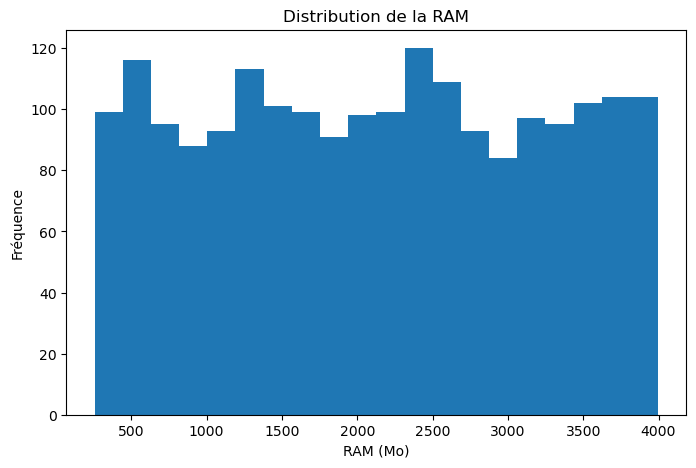

In [51]:
plt.figure(figsize=(8,5))

plt.hist(df['ram'], bins=20)

plt.title('Distribution de la RAM')
plt.xlabel('RAM (Mo)')
plt.ylabel('Fréquence')

plt.show()

L'histogramme montre que les valeurs de ram sont répartie de manière presque uniforme entre 250 et 4000mo et ne sont pas concentrer dans une seul zone et aussi ne présente pas d'asymétrie importante de la gauche vers la droite

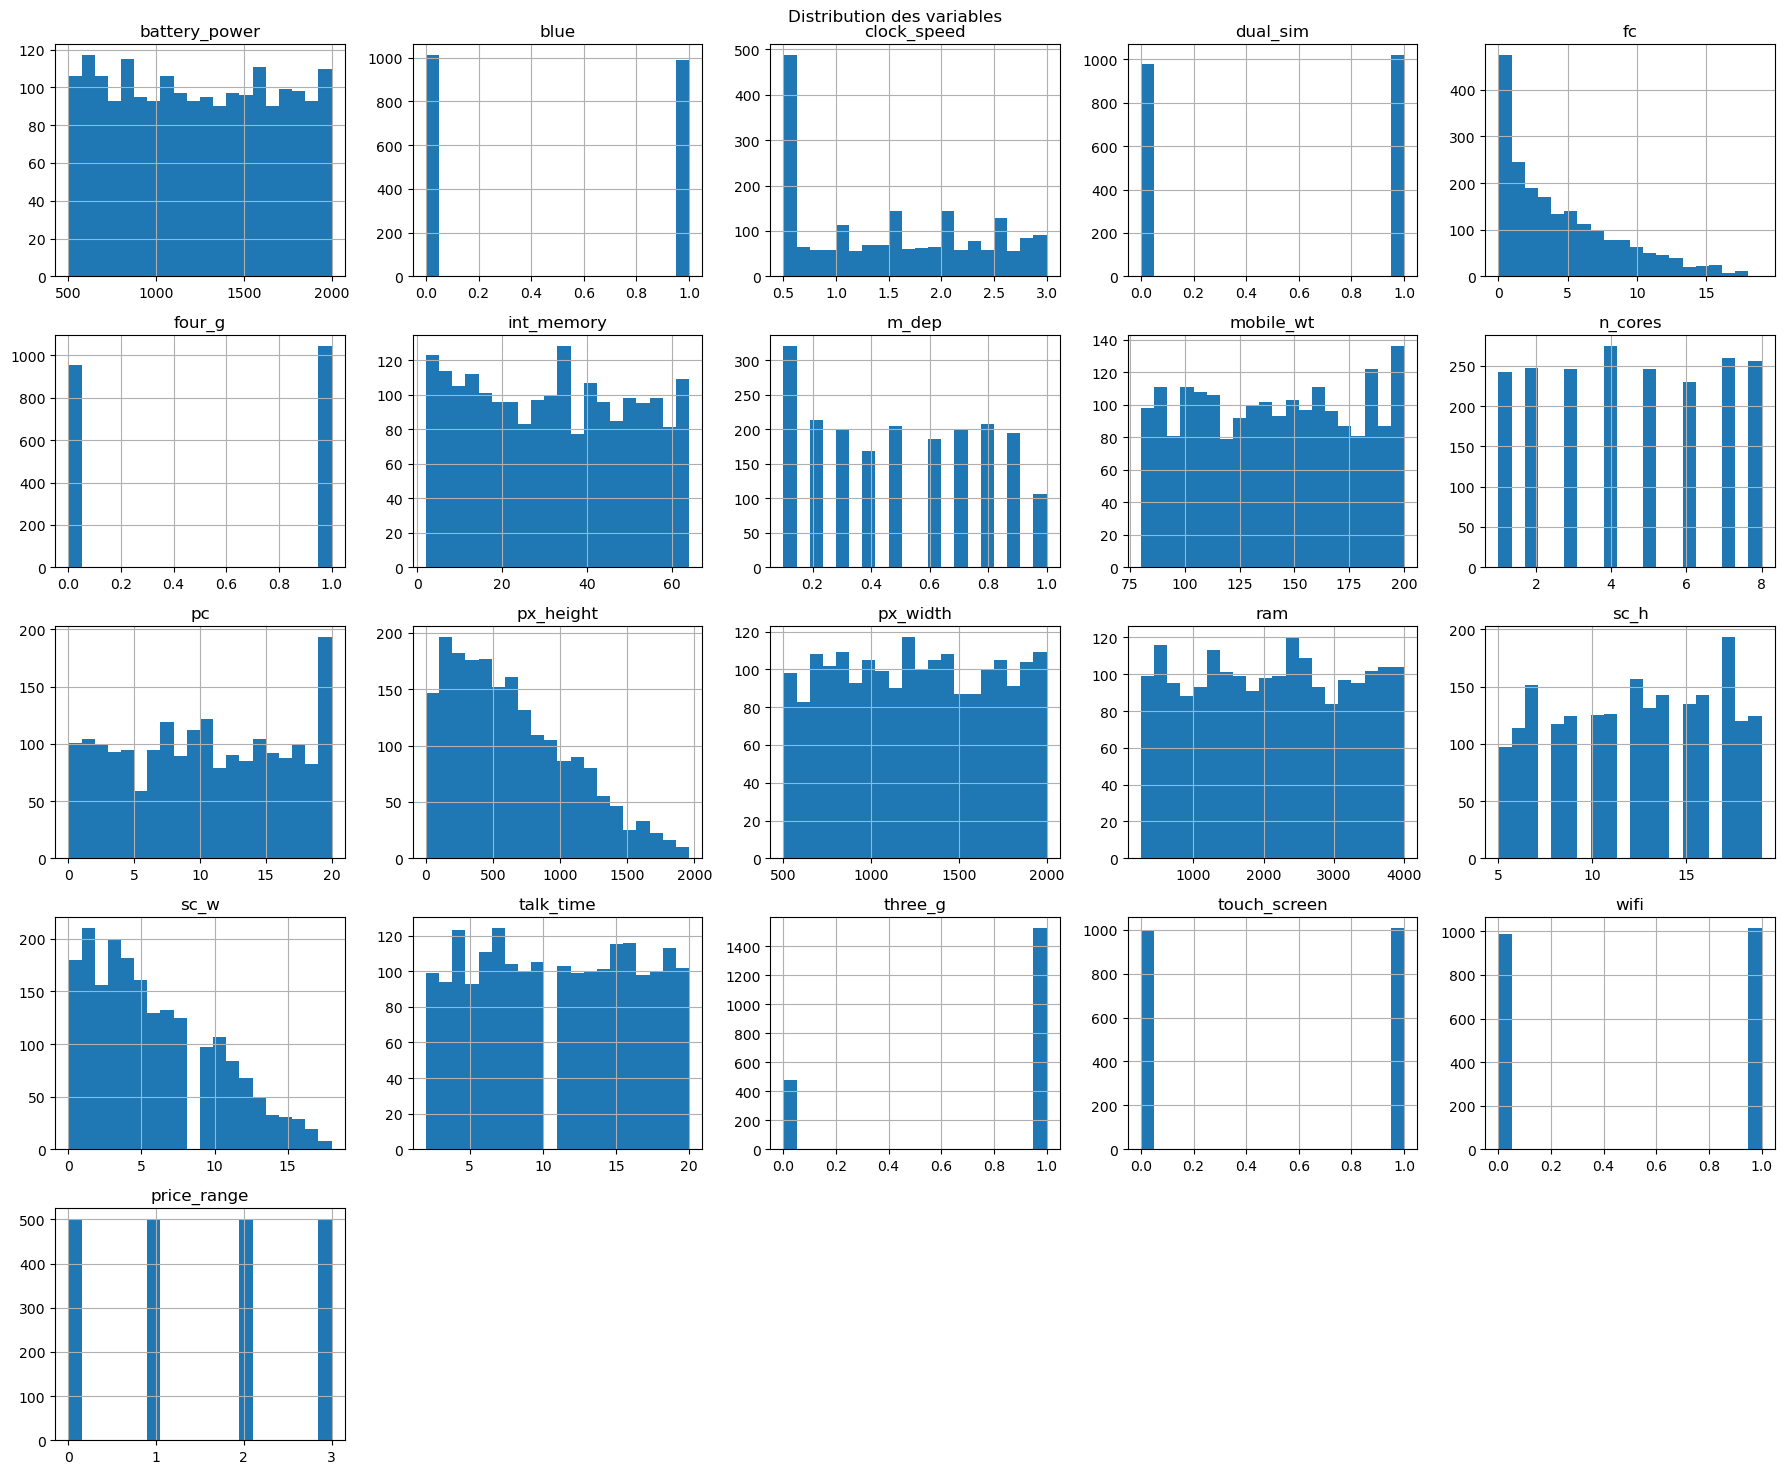

In [55]:
df.hist(
    figsize=(18,15),
    bins=20
)

plt.suptitle("Distribution des variables")
plt.tight_layout()

plt.show()

On peut ici voir la distribution des différentes variables qauntitative

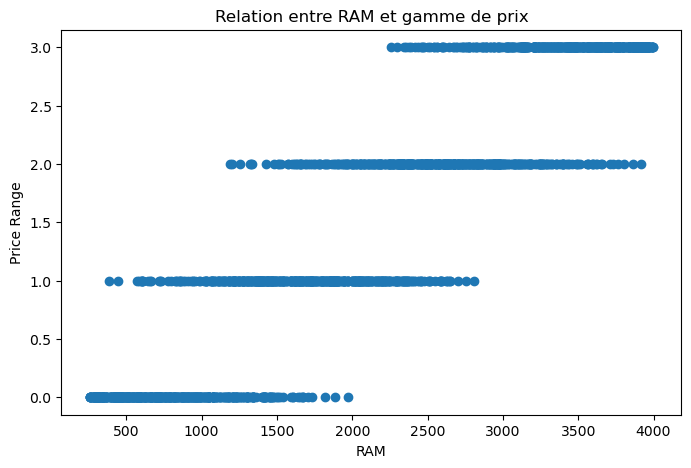

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['ram'],
    df['price_range']
)

plt.title("Relation entre RAM et gamme de prix")
plt.xlabel("RAM")
plt.ylabel("Price Range")

plt.show()

On constate que plus la ram est beaucoup, plus le téléphone a un bon prix

### **Carte thermique des corrélations**

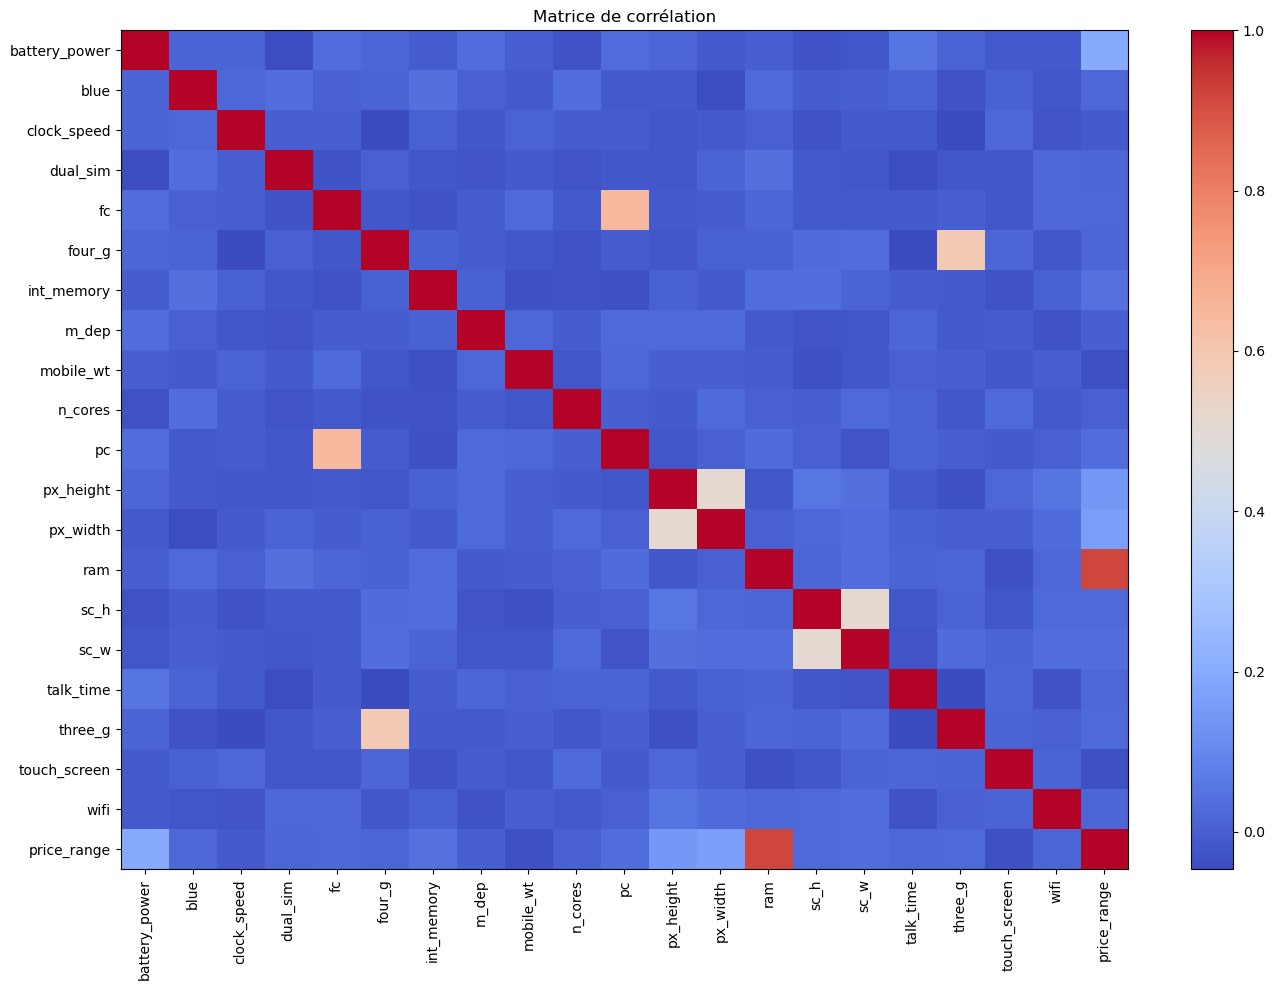

In [63]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    aspect='auto',
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Matrice de corrélation")

plt.tight_layout()
plt.show()

## **5. Insight Synthesis and Conclusion:**

Dans les différents tests effectuer, nous avons trouver que la ram avait une frote corrélation avec price_range, ce qui suggère que plus la capicité de la ram augmente, plus le prix est supérieure. quantités moyennes de RAM diffèrent significativement entre les différentes gammes de prix. Cette observation est confirmée par le test ANOVA, dont la p-value est inférieure à 0,05. Le test révèle ainsi des différences statistiquement significatives des moyennes de RAM entre les différentes gammes de prix.  
De plus, hormis la ram, on peut avoir la puissance de la battery ou encore la la resolution.